# Base vs. Instruction-Tuned Models — BLiMP & EWoK

This notebook analyzes the layer-by-layer logit-lens scores in `../results/`
(produced by `scripts/get_probs.py`). Every model — base **and**
instruction-tuned — was scored at **every layer**: the model's own final
unembedding matrix is applied to each intermediate hidden state, giving a
logprob (and accuracy) curve across depth, not just a single final-layer
number.

Two questions:

1. **Base vs. instruction-tuned** — do the two variants of the same model
   family differ in BLiMP / EWoK accuracy (using each model's own final
   layer, i.e. the standard, "real" prediction)?
2. **Does the base model's (final-layer) accuracy show up in the low/middle
   layers of the instruction-tuned model?** I.e. does instruction tuning
   mostly add a few layers of "formatting" on top of a base-model-like
   representation that is already present partway through the network?

Metric: `sent1_logprob_greater` — whether the model assigns higher total
log-probability to the grammatical / plausible sentence in each minimal
pair (the standard BLiMP/EWoK accuracy). A length-normalized alternative
(`sent1_avg_logprob_greater`) is also loaded if you want to swap it in.

In [15]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ---- paths ----------------------------------------------------------------
RESULTS_DIR = Path("../results")
assert RESULTS_DIR.exists(), f"Can't find {RESULTS_DIR.resolve()} — run this notebook from notebooks/"

# instruction-tuned models are scored separately in ../results_instruct/: each
# sentence is wrapped in the model's own chat template behind a fixed
# instruction (see scripts/get_probs_instruct.py), so the "it" models are
# evaluated the way they're actually used rather than as bare-sentence base
# models. Base models still come from RESULTS_DIR.
INSTRUCT_RESULTS_DIR = Path("../results_instruct")
assert INSTRUCT_RESULTS_DIR.exists(), f"Can't find {INSTRUCT_RESULTS_DIR.resolve()} — run this notebook from notebooks/"

CACHE_PATH = Path("layer_acc_cache.csv")  # delete this file to force a re-read of the tsvs

# ---- palette (validated categorical + status colors) -----------------------
COLOR_BASE = "#2a78d6"   # blue   -> "base" model, fixed identity color
COLOR_IT   = "#eb6834"   # orange -> "instruction-tuned" model, fixed identity color
COLOR_GOOD = "#0ca30c"   # instruction-tuning improved accuracy
COLOR_BAD  = "#d03b3b"   # instruction-tuning hurt accuracy
GRID_COLOR = "#e1e0d9"
MUTED = "#898781"
TEXT = "#0b0b0b"
BAND = "#f0efec"
BAND2 = "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": TEXT,
    "text.color": TEXT,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "grid.color": GRID_COLOR,
    "axes.grid": True,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# ---- model families (base_name, it_name), from scripts/utils/models.py ----
MODEL_FAMILIES = {
    "Llama-3.2-1B": ("Llama-3.2-1B", "Llama-3.2-1B-it"),
    "Llama-3.2-3B": ("Llama-3.2-3B", "Llama-3.2-3B-it"),
    "Llama-3.1-8B": ("Llama-3.1-8B", "Llama-3.1-8B-it"),
    "Gemma-3-1B":   ("Gemma-3-1B", "Gemma-3-1B-it"),
    "Gemma-3-4B":   ("Gemma-3-4B", "Gemma-3-4B-it"),
    "Mistral-7B":   ("Mistral-7B", "Mistral-7B-it"),
    "Qwen-2.5-7B":  ("Qwen-2.5-7B", "Qwen-2.5-7B-it"),
    "Qwen-3-4B":    ("Qwen-3-4B", "Qwen-3-4B-it"),
    "Falcon-3-1B":  ("Falcon-3-1B", "Falcon-3-1B-it"),
    "Falcon-3-7B":  ("Falcon-3-7B", "Falcon-3-7B-it"),
    "Olmo-3-7B":    ("Olmo-3-7B", "Olmo-3-7B-it"),
}

BLIMP_TASK_IDS = [str(i) for i in range(67)]
EWOK_DIR_NAME = "ewok-ewok-core-1.0"

ACC_COL = "acc_sum"  # primary metric: full-sequence logprob comparison (standard BLiMP/EWoK accuracy)
                      # swap to "acc_avg" for the length-normalized, per-token variant

## Load & aggregate

Each `*_scored.tsv` has one row per (sentence pair, layer). We only need three columns to get per-layer accuracy, so we avoid loading the sentence text at all and aggregate immediately — this keeps memory small even though the full sweep is tens of millions of rows across ~1,500 files. Results are cached to `layer_acc_cache.csv` after the first run.

In [16]:
USECOLS = ["layer", "sent1_logprob_greater", "sent1_avg_logprob_greater"]

def load_layer_summary(model_dir: Path, dataset: str):
    """Per-layer accuracy for one model+dataset, macro-averaged across tasks/domains."""
    if dataset == "blimp":
        paths = [model_dir / tid / f"{tid}_scored.tsv" for tid in BLIMP_TASK_IDS]
    else:
        paths = [model_dir / EWOK_DIR_NAME / f"{EWOK_DIR_NAME}_scored.tsv"]

    per_task = []
    for path in paths:
        if not path.exists():
            continue
        df = pd.read_csv(path, sep="\t", usecols=USECOLS)
        g = df.groupby("layer").agg(
            n=("sent1_logprob_greater", "size"),
            acc_sum=("sent1_logprob_greater", "mean"),
            acc_avg=("sent1_avg_logprob_greater", "mean"),
        ).reset_index()
        per_task.append(g)

    if not per_task:
        return None

    combined = pd.concat(per_task, ignore_index=True)
    # macro-average: each BLiMP paradigm / EWoK domain counts equally, regardless of size
    return combined.groupby("layer").agg(
        acc_sum=("acc_sum", "mean"),
        acc_avg=("acc_avg", "mean"),
        n=("n", "sum"),
    ).reset_index()

In [17]:
if CACHE_PATH.exists():
    layer_acc = pd.read_csv(CACHE_PATH)
    print(f"Loaded cached summary: {layer_acc.shape}")
else:
    try:
        from tqdm.auto import tqdm
        family_iter = tqdm(list(MODEL_FAMILIES.items()))
    except ImportError:
        family_iter = MODEL_FAMILIES.items()

    records = []
    for family, (base_name, it_name) in family_iter:
        for variant, model_name, variant_dir in [
            ("base", base_name, RESULTS_DIR),
            ("it", it_name, INSTRUCT_RESULTS_DIR),
        ]:
            model_dir = variant_dir / model_name
            if not model_dir.exists():
                print(f"Missing model dir: {model_dir}")
                continue
            for dataset in ["blimp", "ewok"]:
                summary = load_layer_summary(model_dir, dataset)
                if summary is None:
                    print(f"No data for {model_name} / {dataset}")
                    continue
                summary["family"] = family
                summary["variant"] = variant
                summary["model"] = model_name
                summary["dataset"] = dataset
                records.append(summary)

    layer_acc = pd.concat(records, ignore_index=True)
    layer_acc["max_layer"] = layer_acc.groupby("model")["layer"].transform("max")
    layer_acc["rel_depth"] = layer_acc["layer"] / layer_acc["max_layer"]
    layer_acc.to_csv(CACHE_PATH, index=False)
    print(f"Built summary: {layer_acc.shape}")

layer_acc.head()

Loaded cached summary: (1240, 10)


,layer,acc_sum,acc_avg,n,family,variant,model,dataset,max_layer,rel_depth
0,1,0.147970,0.100985,67000,Llama-3.2-1B,base,Llama-3.2-1B,blimp,16,0.0625
1,2,0.185269,0.169806,67000,Llama-3.2-1B,base,Llama-3.2-1B,blimp,16,0.1250
2,3,0.214060,0.200209,67000,Llama-3.2-1B,base,Llama-3.2-1B,blimp,16,0.1875
3,4,0.232224,0.220731,67000,Llama-3.2-1B,base,Llama-3.2-1B,blimp,16,0.2500
4,5,0.242328,0.231328,67000,Llama-3.2-1B,base,Llama-3.2-1B,blimp,16,0.3125


## 1. Base vs. instruction-tuned: final-layer accuracy

Each model's own top layer is its real, standard output. This compares that number between the base and instruction-tuned checkpoint of each family.

In [18]:
final_acc = layer_acc.loc[layer_acc.groupby(["model", "dataset"])["layer"].idxmax()].copy()

final_pivot = (
    final_acc.pivot_table(index=["family", "dataset"], columns="variant", values=ACC_COL)
    .reset_index()
)
final_pivot["delta"] = final_pivot["it"] - final_pivot["base"]

# consistent family ordering across every chart below: by base BLiMP accuracy, descending
order = (
    final_pivot[final_pivot["dataset"] == "blimp"]
    .sort_values("base", ascending=False)["family"]
    .tolist()
)

final_pivot.sort_values(["dataset", "base"], ascending=[True, False])

variant,family,dataset,base,it,delta
16,Olmo-3-7B,blimp,0.823343,0.675343,-0.148000
14,Mistral-7B,blimp,0.822881,0.722627,-0.100254
0,Falcon-3-1B,blimp,0.809910,0.760179,-0.049731
2,Falcon-3-7B,blimp,0.809597,0.797642,-0.011955
18,Qwen-2.5-7B,blimp,0.807015,0.657403,-0.149612
10,Llama-3.2-1B,blimp,0.805164,0.741313,-0.063851
8,Llama-3.1-8B,blimp,0.798254,0.755254,-0.043000
12,Llama-3.2-3B,blimp,0.796134,0.721269,-0.074866
6,Gemma-3-4B,blimp,0.777403,0.607866,-0.169537
4,Gemma-3-1B,blimp,0.773299,0.699791,-0.073507


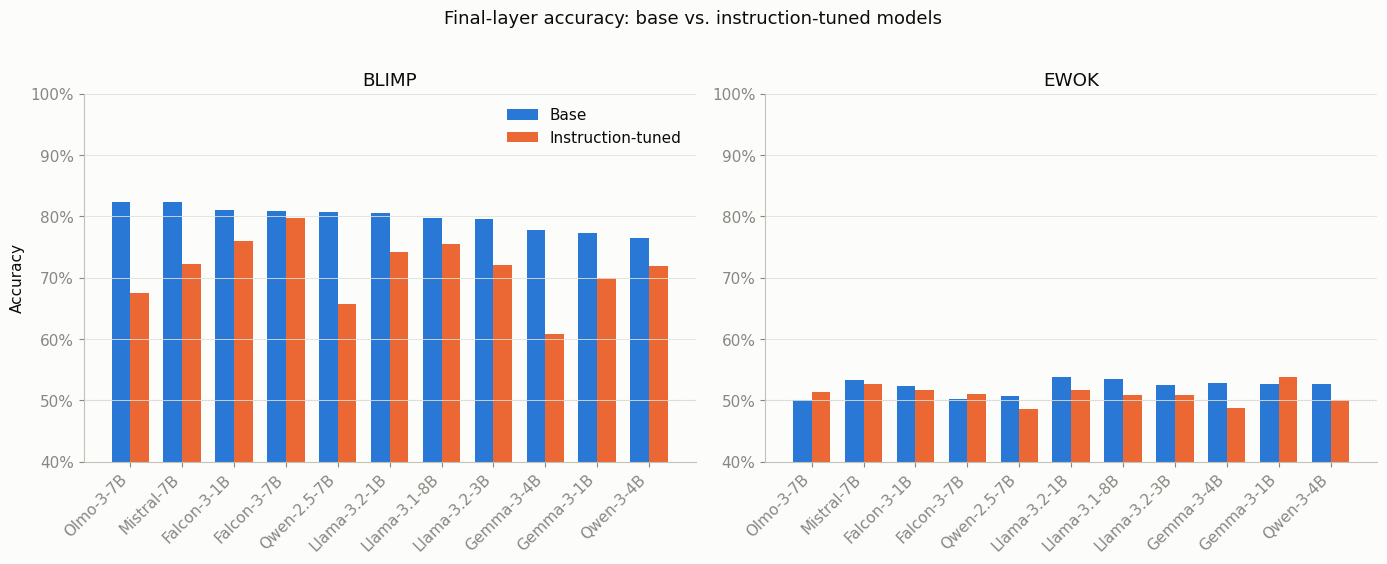

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
x = np.arange(len(order))
width = 0.36

for ax, dataset in zip(axes, ["blimp", "ewok"]):
    sub = final_pivot[final_pivot["dataset"] == dataset].set_index("family").loc[order]
    ax.bar(x - width / 2, sub["base"] * 100, width, color=COLOR_BASE, label="Base")
    ax.bar(x + width / 2, sub["it"] * 100, width, color=COLOR_IT, label="Instruction-tuned")
    ax.axhline(50, color=MUTED, linewidth=0.8, linestyle=":", zorder=0)
    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=45, ha="right")
    ax.set_title(dataset.upper())
    ax.set_ylim(40, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
    ax.grid(axis="x", visible=False)

axes[0].set_ylabel("Accuracy")
axes[0].legend(frameon=False, loc="upper right")
fig.suptitle("Final-layer accuracy: base vs. instruction-tuned models", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

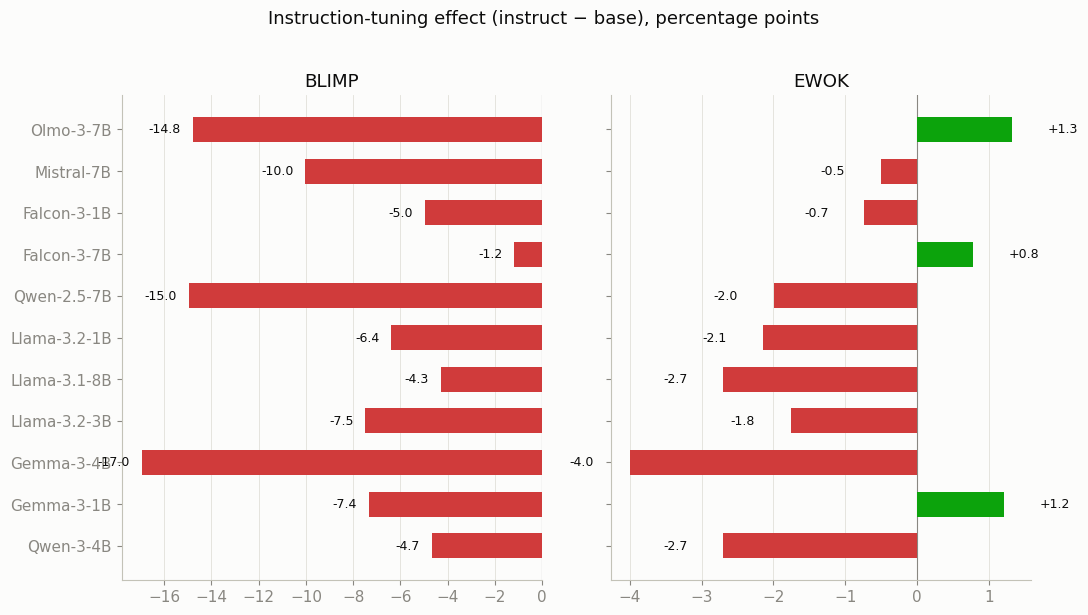

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 6), sharey=True)
y = np.arange(len(order))

for ax, dataset in zip(axes, ["blimp", "ewok"]):
    sub = final_pivot[final_pivot["dataset"] == dataset].set_index("family").loc[order]
    deltas = sub["delta"] * 100
    colors = [COLOR_GOOD if v >= 0 else COLOR_BAD for v in deltas]
    ax.barh(y, deltas, color=colors, height=0.6, zorder=3)
    ax.axvline(0, color=MUTED, linewidth=0.8)
    for yi, v in zip(y, deltas):
        ax.text(v + (0.5 if v >= 0 else -0.5), yi, f"{v:+.1f}", va="center",
                 ha="left" if v >= 0 else "right", fontsize=9, color=TEXT)
    ax.set_title(dataset.upper())
    ax.grid(axis="y", visible=False)

axes[0].set_yticks(y)
axes[0].set_yticklabels(order)
axes[0].invert_yaxis()
fig.suptitle("Instruction-tuning effect (instruct \u2212 base), percentage points", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

## 2. Does base-model accuracy show up in the low/middle layers of the instruction-tuned model?

For each family, we plot both models' full logit-lens accuracy curve against **layer index** (base and instruction-tuned share the same architecture and layer count within a family, so no depth normalization is needed here). The dashed blue line marks the **base model's final-layer accuracy**; the marker on the orange curve is the instruction-tuned layer whose accuracy is closest to that value.

**Caveat:** this is a plain logit lens (each model's own unembedding applied to its own intermediate states, no tuned/calibrated lens), so early-layer probabilities can be systematically off — read the matched layer as a directional signal, not a literal claim that the network 'has decided' the base answer by that point.

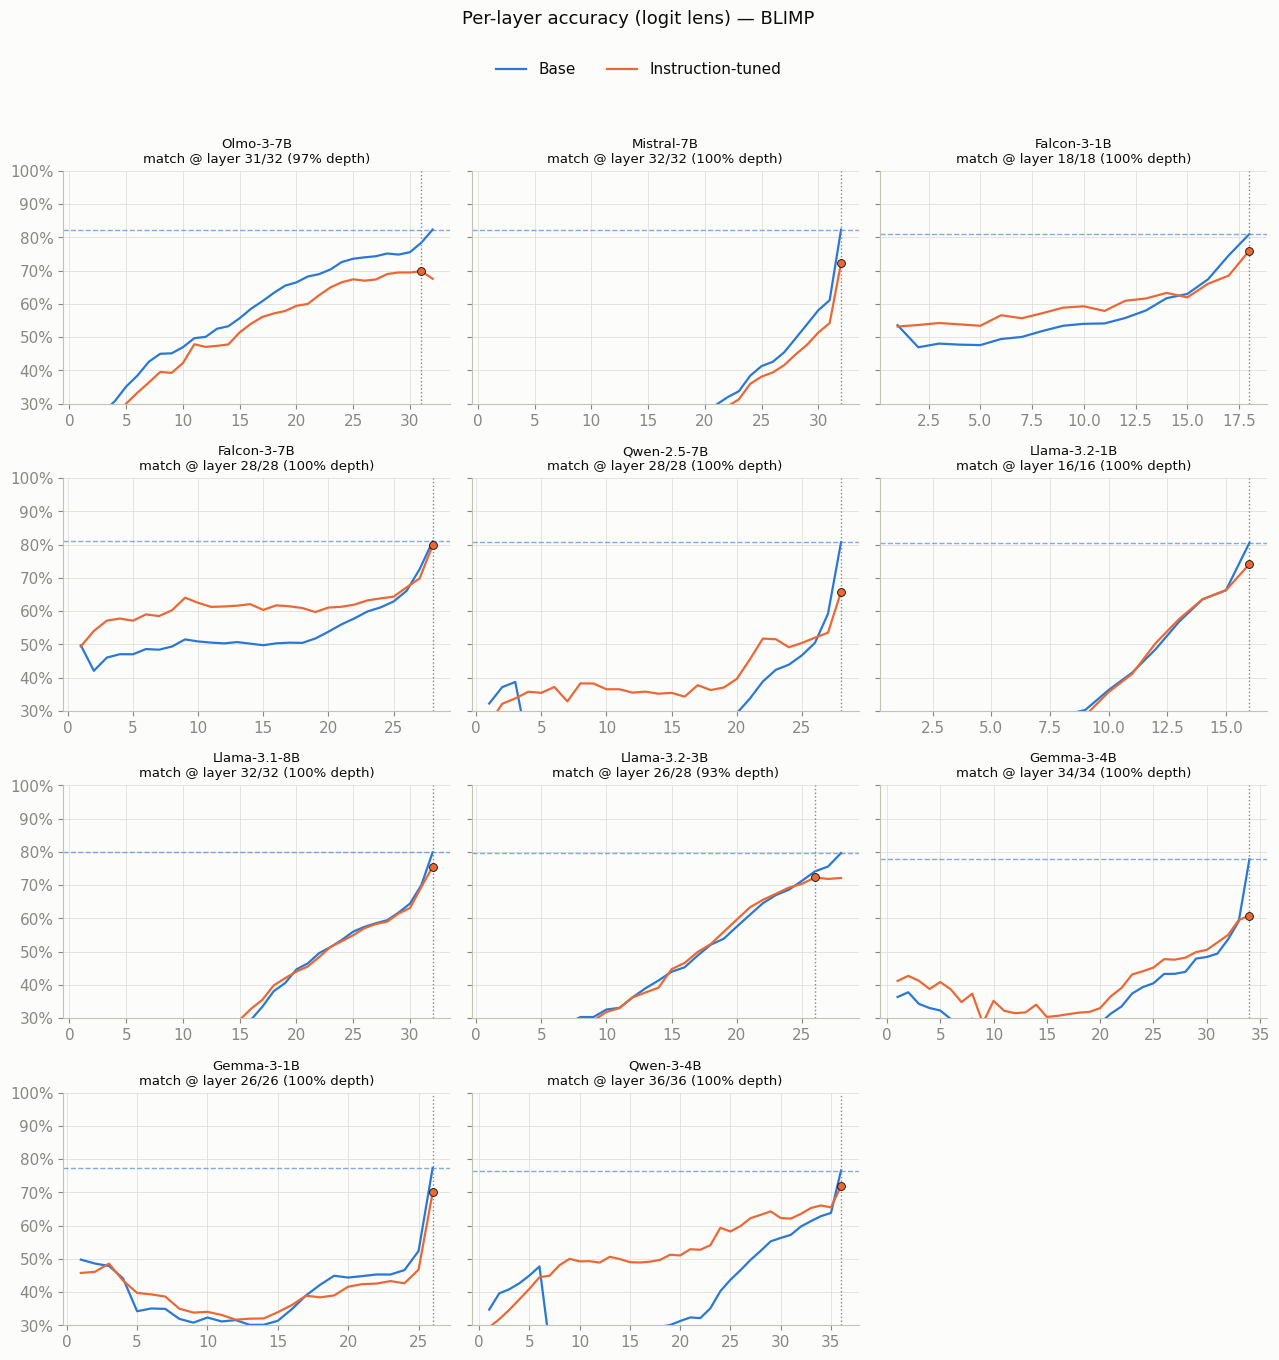

In [21]:
def closest_matching_layer(it_curve, target_value):
    idx = (it_curve[ACC_COL] - target_value).abs().idxmin()
    row = it_curve.loc[idx]
    return row["layer"], row["rel_depth"], row[ACC_COL]


def plot_layer_grid(dataset, ncols=3):
    nrows = int(np.ceil(len(order) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.3 * ncols, 3.2 * nrows), sharey=True)
    axes = axes.flatten()

    match_rows = []
    for ax, family in zip(axes, order):
        base_curve = layer_acc[(layer_acc.family == family) & (layer_acc.variant == "base") & (layer_acc.dataset == dataset)].sort_values("layer")
        it_curve = layer_acc[(layer_acc.family == family) & (layer_acc.variant == "it") & (layer_acc.dataset == dataset)].sort_values("layer")
        if base_curve.empty or it_curve.empty:
            ax.axis("off")
            continue

        base_final = base_curve[ACC_COL].iloc[-1]
        m_layer, m_depth, m_acc = closest_matching_layer(it_curve, base_final)
        it_max_layer = int(it_curve["layer"].max())

        ax.plot(base_curve["layer"], base_curve[ACC_COL] * 100, color=COLOR_BASE, linewidth=1.6, label="Base")
        ax.plot(it_curve["layer"], it_curve[ACC_COL] * 100, color=COLOR_IT, linewidth=1.6, label="Instruction-tuned")
        ax.axhline(base_final * 100, color=COLOR_BASE, linewidth=1, linestyle="--", alpha=0.6)
        ax.axvline(m_layer, color=MUTED, linewidth=1, linestyle=":")
        ax.scatter([m_layer], [m_acc * 100], color=COLOR_IT, edgecolor=TEXT, linewidth=0.6, zorder=5, s=32)

        ax.set_title(f"{family}\nmatch @ layer {int(m_layer)}/{it_max_layer} ({m_depth * 100:.0f}% depth)", fontsize=9.5)
        ax.set_ylim(30, 100)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))

        match_rows.append({
            "family": family, "dataset": dataset,
            "base_final_acc": base_final, "it_final_acc": it_curve[ACC_COL].iloc[-1],
            "matched_it_layer": int(m_layer), "matched_it_max_layer": it_max_layer,
            "matched_rel_depth": m_depth, "matched_it_acc": m_acc,
        })

    for ax in axes[len(order):]:
        ax.axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.03))
    fig.suptitle(f"Per-layer accuracy (logit lens) \u2014 {dataset.upper()}", y=1.06, fontsize=13)
    fig.tight_layout()
    plt.show()
    return pd.DataFrame(match_rows)


blimp_matches = plot_layer_grid("blimp")

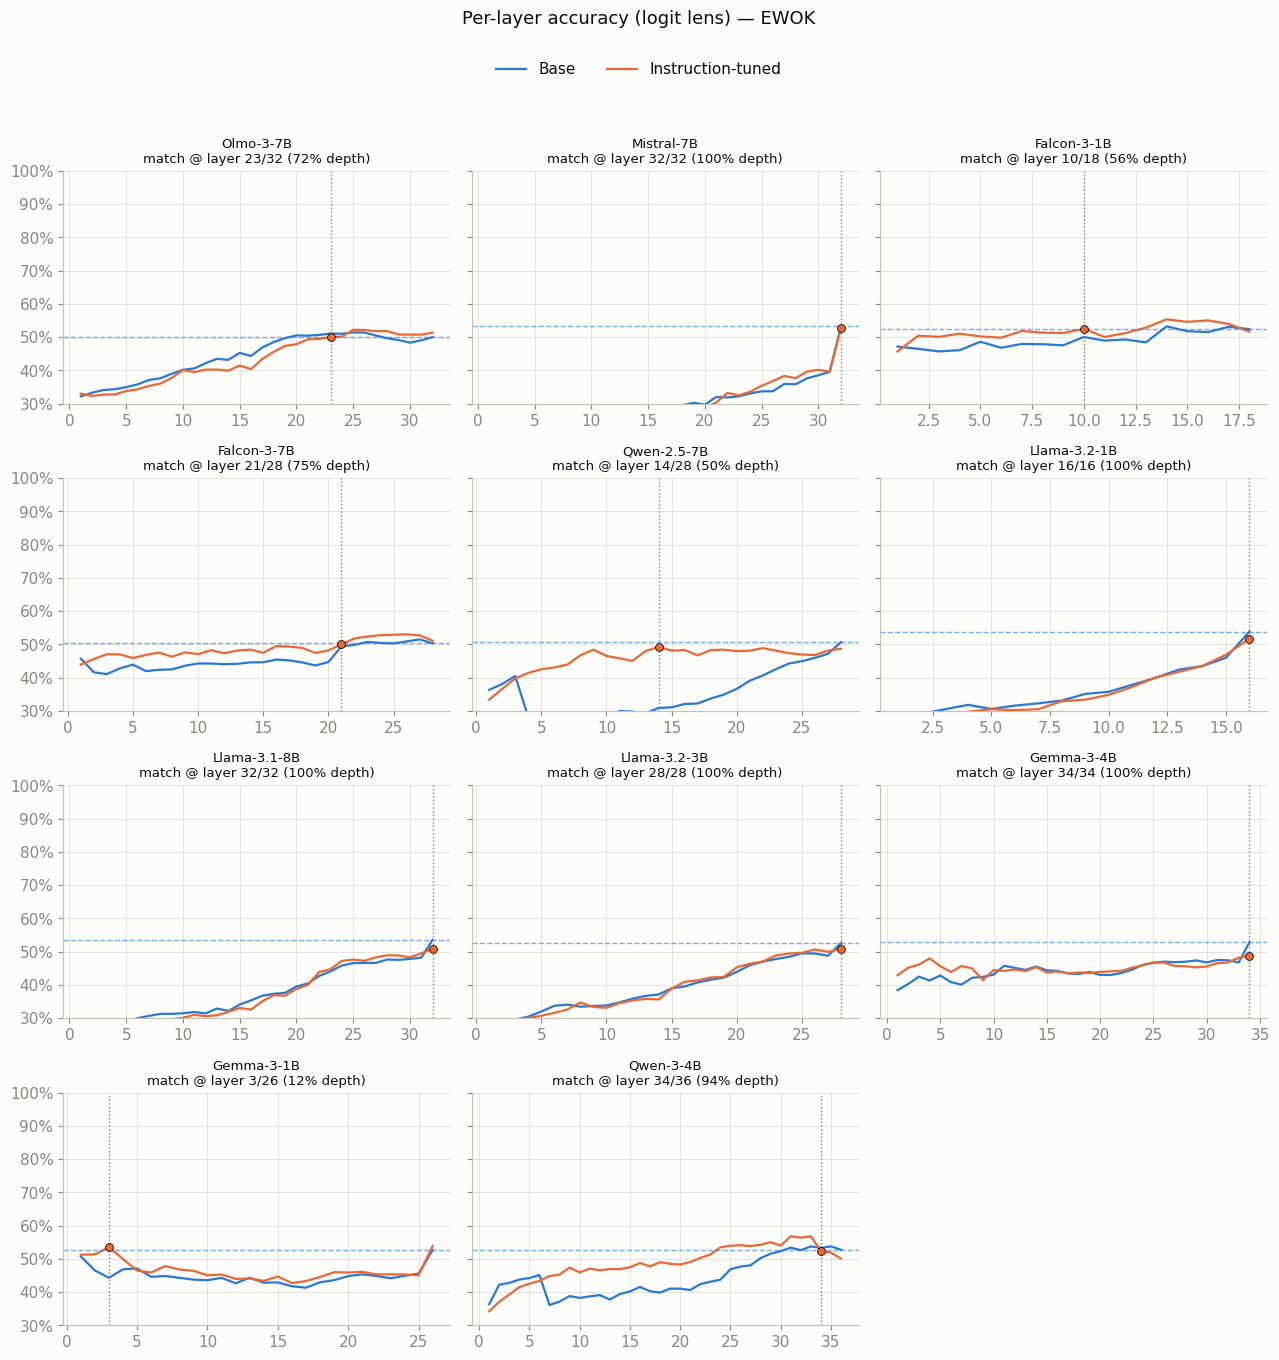

In [22]:
ewok_matches = plot_layer_grid("ewok")

In [23]:
match_df = pd.concat([blimp_matches, ewok_matches], ignore_index=True)
match_df = match_df.sort_values(["dataset", "matched_rel_depth"]).reset_index(drop=True)
match_df

,family,dataset,base_final_acc,it_final_acc,matched_it_layer,matched_it_max_layer,matched_rel_depth,matched_it_acc
0,Llama-3.2-3B,blimp,0.796134,0.721269,26,28,0.928571,0.722881
1,Olmo-3-7B,blimp,0.823343,0.675343,31,32,0.968750,0.698119
2,Mistral-7B,blimp,0.822881,0.722627,32,32,1.000000,0.722627
3,Falcon-3-1B,blimp,0.809910,0.760179,18,18,1.000000,0.760179
4,Falcon-3-7B,blimp,0.809597,0.797642,28,28,1.000000,0.797642
5,Qwen-2.5-7B,blimp,0.807015,0.657403,28,28,1.000000,0.657403
6,Llama-3.2-1B,blimp,0.805164,0.741313,16,16,1.000000,0.741313
7,Llama-3.1-8B,blimp,0.798254,0.755254,32,32,1.000000,0.755254
8,Gemma-3-4B,blimp,0.777403,0.607866,34,34,1.000000,0.607866
9,Gemma-3-1B,blimp,0.773299,0.699791,26,26,1.000000,0.699791


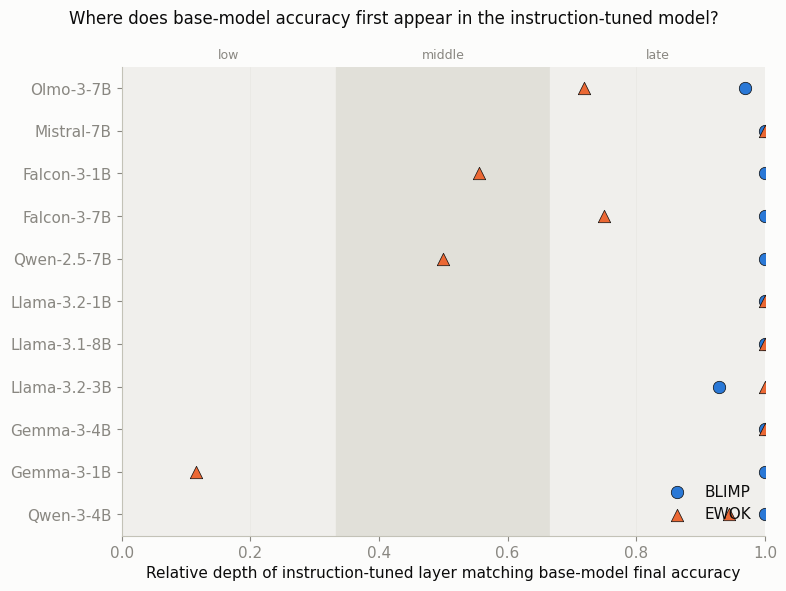

blimp: base-final accuracy matched in low/middle layers (<66% depth) for 0% of families (median matched depth = 100%)
ewok : base-final accuracy matched in low/middle layers (<66% depth) for 27% of families (median matched depth = 94%)


In [24]:
fig, ax = plt.subplots(figsize=(8, 6))
y = np.arange(len(order))

ax.axvspan(0, 1 / 3, color=BAND, zorder=0)
ax.axvspan(1 / 3, 2 / 3, color=BAND2, zorder=0)
ax.axvspan(2 / 3, 1, color=BAND, zorder=0)

markers = {"blimp": ("o", COLOR_BASE), "ewok": ("^", COLOR_IT)}
for dataset, (marker, color) in markers.items():
    ys, xs = [], []
    for i, family in enumerate(order):
        row = match_df[(match_df.family == family) & (match_df.dataset == dataset)]
        if not row.empty:
            ys.append(i)
            xs.append(row["matched_rel_depth"].iloc[0])
    ax.scatter(xs, ys, marker=marker, color=color, s=80, zorder=5, edgecolor=TEXT, linewidth=0.5, label=dataset.upper())

ax.set_yticks(y)
ax.set_yticklabels(order)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("Relative depth of instruction-tuned layer matching base-model final accuracy")
ax.text(1 / 6, -0.7, "low", ha="center", color=MUTED, fontsize=9)
ax.text(0.5, -0.7, "middle", ha="center", color=MUTED, fontsize=9)
ax.text(5 / 6, -0.7, "late", ha="center", color=MUTED, fontsize=9)
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="x", alpha=0.4)
ax.grid(axis="y", visible=False)
fig.suptitle("Where does base-model accuracy first appear in the instruction-tuned model?", fontsize=12)
fig.tight_layout()
plt.show()

for dataset in ["blimp", "ewok"]:
    sub = match_df[match_df.dataset == dataset]
    frac_lowmid = (sub["matched_rel_depth"] < 2 / 3).mean()
    print(f"{dataset:5s}: base-final accuracy matched in low/middle layers (<66% depth) for "
          f"{frac_lowmid * 100:.0f}% of families (median matched depth = {sub['matched_rel_depth'].median() * 100:.0f}%)")

## 3. Correct vs. incorrect, by linguistic category

Aggregate accuracy hides *where* each variant fails. This breaks the final-layer
accuracy down by category — BLiMP's `linguistics_term` (the 13 phenomenon
groups the paradigms fall into) and EWoK's `field` (its 11 domains) — and
shows correct vs. incorrect as a 100%-stacked bar per category, base next to
instruct. One panel per model family (categories within each panel sorted by
base-model accuracy, ascending).

In [25]:
CATEGORY_CACHE_PATH = Path("category_acc_cache.csv")
USECOLS_CAT = ["layer", "sent1_logprob_greater", "field", "linguistics_term"]
CATEGORY_COL = {"blimp": "linguistics_term", "ewok": "field"}


def load_final_layer_category_summary(model_dir: Path, dataset: str):
    """Final-layer correct/incorrect counts per category (no cross-layer aggregation)."""
    if dataset == "blimp":
        paths = [model_dir / tid / f"{tid}_scored.tsv" for tid in BLIMP_TASK_IDS]
    else:
        paths = [model_dir / EWOK_DIR_NAME / f"{EWOK_DIR_NAME}_scored.tsv"]
    cat_col = CATEGORY_COL[dataset]

    per_task = []
    for path in paths:
        if not path.exists():
            continue
        df = pd.read_csv(path, sep="\t", usecols=USECOLS_CAT)
        final = df[df["layer"] == df["layer"].max()]
        g = final.groupby(cat_col).agg(
            n=("sent1_logprob_greater", "size"),
            n_correct=("sent1_logprob_greater", "sum"),
        ).reset_index().rename(columns={cat_col: "category"})
        per_task.append(g)

    if not per_task:
        return None

    combined = pd.concat(per_task, ignore_index=True)
    return combined.groupby("category").agg(
        n=("n", "sum"), n_correct=("n_correct", "sum"),
    ).reset_index()

In [26]:
if CATEGORY_CACHE_PATH.exists():
    category_acc = pd.read_csv(CATEGORY_CACHE_PATH)
    print(f"Loaded cached category summary: {category_acc.shape}")
else:
    try:
        from tqdm.auto import tqdm
        family_iter = tqdm(list(MODEL_FAMILIES.items()))
    except ImportError:
        family_iter = MODEL_FAMILIES.items()

    records = []
    for family, (base_name, it_name) in family_iter:
        for variant, model_name, variant_dir in [
            ("base", base_name, RESULTS_DIR),
            ("it", it_name, INSTRUCT_RESULTS_DIR),
        ]:
            model_dir = variant_dir / model_name
            if not model_dir.exists():
                continue
            for dataset in ["blimp", "ewok"]:
                summary = load_final_layer_category_summary(model_dir, dataset)
                if summary is None:
                    continue
                summary["family"] = family
                summary["variant"] = variant
                summary["dataset"] = dataset
                records.append(summary)

    category_acc = pd.concat(records, ignore_index=True)
    category_acc["n_incorrect"] = category_acc["n"] - category_acc["n_correct"]
    category_acc["accuracy"] = category_acc["n_correct"] / category_acc["n"]
    category_acc.to_csv(CATEGORY_CACHE_PATH, index=False)
    print(f"Built category summary: {category_acc.shape}")

category_acc.head()

Loaded cached category summary: (528, 8)


,category,n,n_correct,family,variant,dataset,n_incorrect,accuracy
0,anaphor_agreement,2000,1984,Llama-3.2-1B,base,blimp,16,0.992000
1,argument_structure,7000,5831,Llama-3.2-1B,base,blimp,1169,0.833000
2,binding,7000,5425,Llama-3.2-1B,base,blimp,1575,0.775000
3,control_raising,5000,4108,Llama-3.2-1B,base,blimp,892,0.821600
4,determiner_noun_agreement,8000,7459,Llama-3.2-1B,base,blimp,541,0.932375


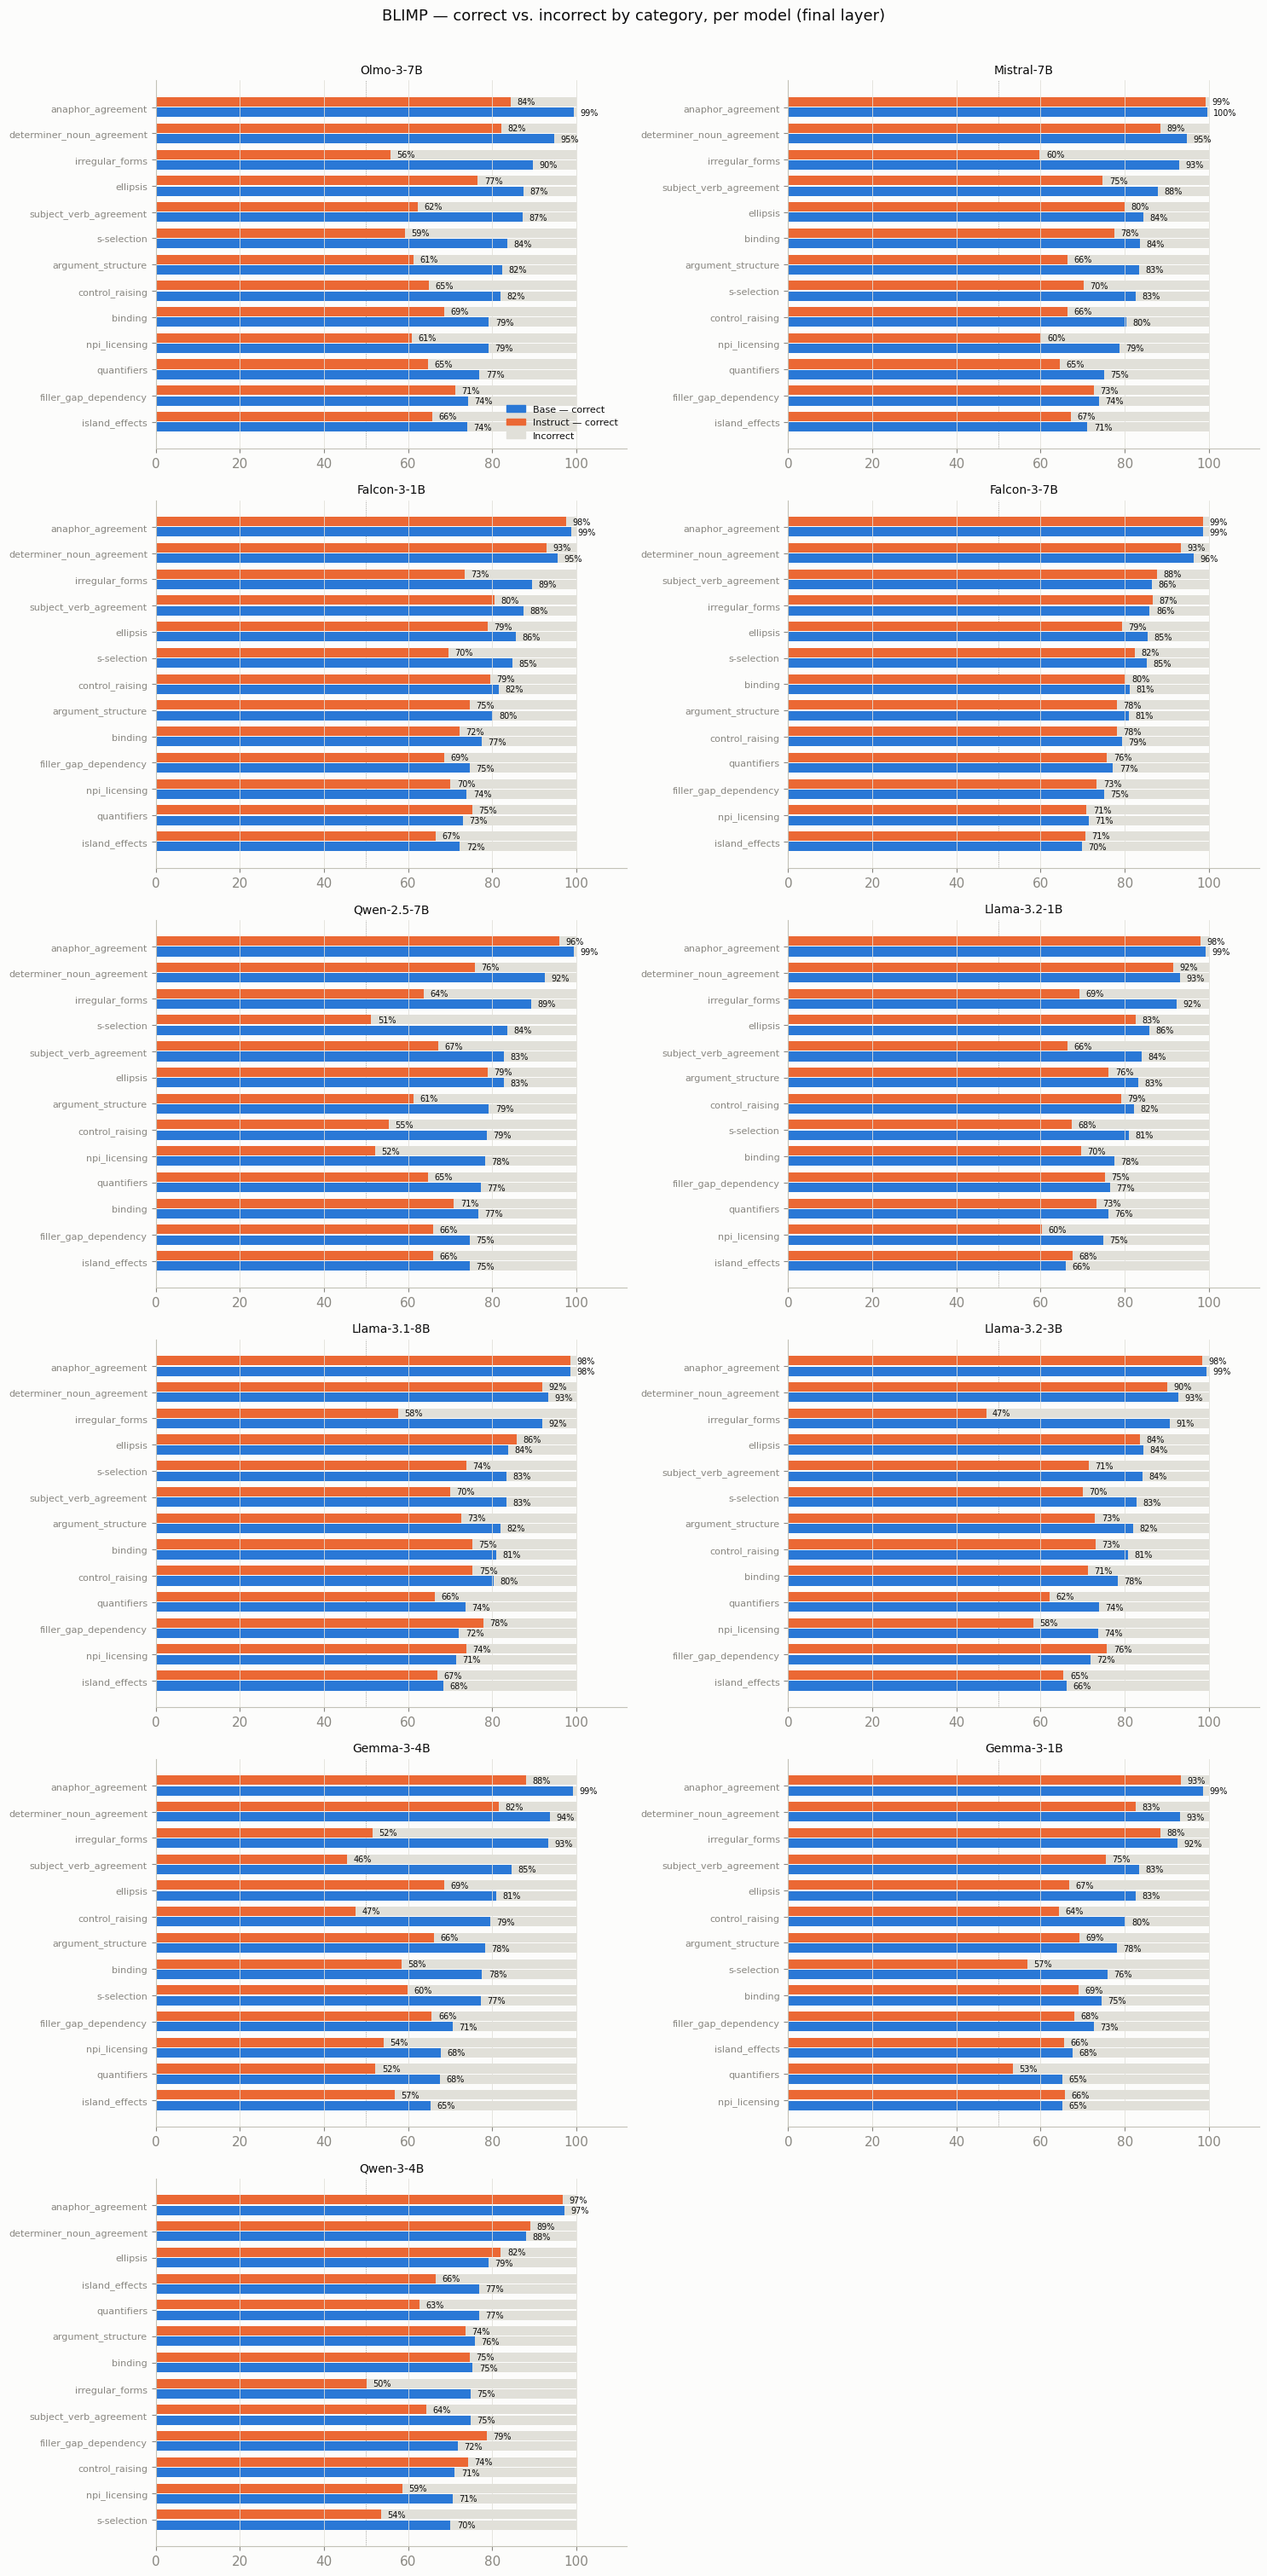

In [27]:
# per-family accuracy per category (no cross-family averaging)
category_summary = (
    category_acc.groupby(["dataset", "variant", "family", "category"])["accuracy"]
    .mean()
    .reset_index()
)


def plot_correct_incorrect(dataset, family, ax, show_legend=False):
    cats = (
        category_summary[
            (category_summary.dataset == dataset)
            & (category_summary.variant == "base")
            & (category_summary.family == family)
        ]
        .sort_values("accuracy", ascending=True)["category"]
        .tolist()
    )
    y = np.arange(len(cats))
    bar_h = 0.36

    for offset, variant, color in [(bar_h / 2 + 0.02, "it", COLOR_IT), (-bar_h / 2 - 0.02, "base", COLOR_BASE)]:
        sub = (
            category_summary[
                (category_summary.dataset == dataset)
                & (category_summary.variant == variant)
                & (category_summary.family == family)
            ]
            .set_index("category")
            .loc[cats]
        )
        correct = sub["accuracy"].values * 100
        incorrect = 100 - correct
        ax.barh(y + offset, correct, height=bar_h, color=color)
        ax.barh(y + offset, incorrect, left=correct, height=bar_h, color=GRID_COLOR)
        for yi, c in zip(y, correct):
            ax.text(c + 1.5, yi + offset, f"{c:.0f}%", va="center", ha="left", fontsize=7, color=TEXT)

    ax.set_yticks(y)
    ax.set_yticklabels(cats, fontsize=8)
    ax.set_xlim(0, 112)
    ax.axvline(50, color=MUTED, linewidth=0.6, linestyle=":", zorder=0)
    ax.grid(axis="y", visible=False)
    ax.set_title(family, fontsize=10)

    if show_legend:
        from matplotlib.patches import Patch
        legend_handles = [
            Patch(color=COLOR_BASE, label="Base — correct"),
            Patch(color=COLOR_IT, label="Instruct — correct"),
            Patch(color=GRID_COLOR, label="Incorrect"),
        ]
        ax.legend(handles=legend_handles, frameon=False, loc="lower right", fontsize=8)


def plot_correct_incorrect_grid(dataset, ncols=2):
    nrows = int(np.ceil(len(order) / ncols))
    n_cats = category_summary[category_summary.dataset == dataset]["category"].nunique()
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.5 * ncols, 0.55 + 0.42 * n_cats * nrows * 0.9))
    axes = axes.flatten()

    for i, (ax, family) in enumerate(zip(axes, order)):
        plot_correct_incorrect(dataset, family, ax, show_legend=(i == 0))

    for ax in axes[len(order):]:
        ax.axis("off")

    fig.suptitle(f"{dataset.upper()} — correct vs. incorrect by category, per model (final layer)", y=1.005, fontsize=13)
    fig.tight_layout()
    plt.show()


plot_correct_incorrect_grid("blimp")

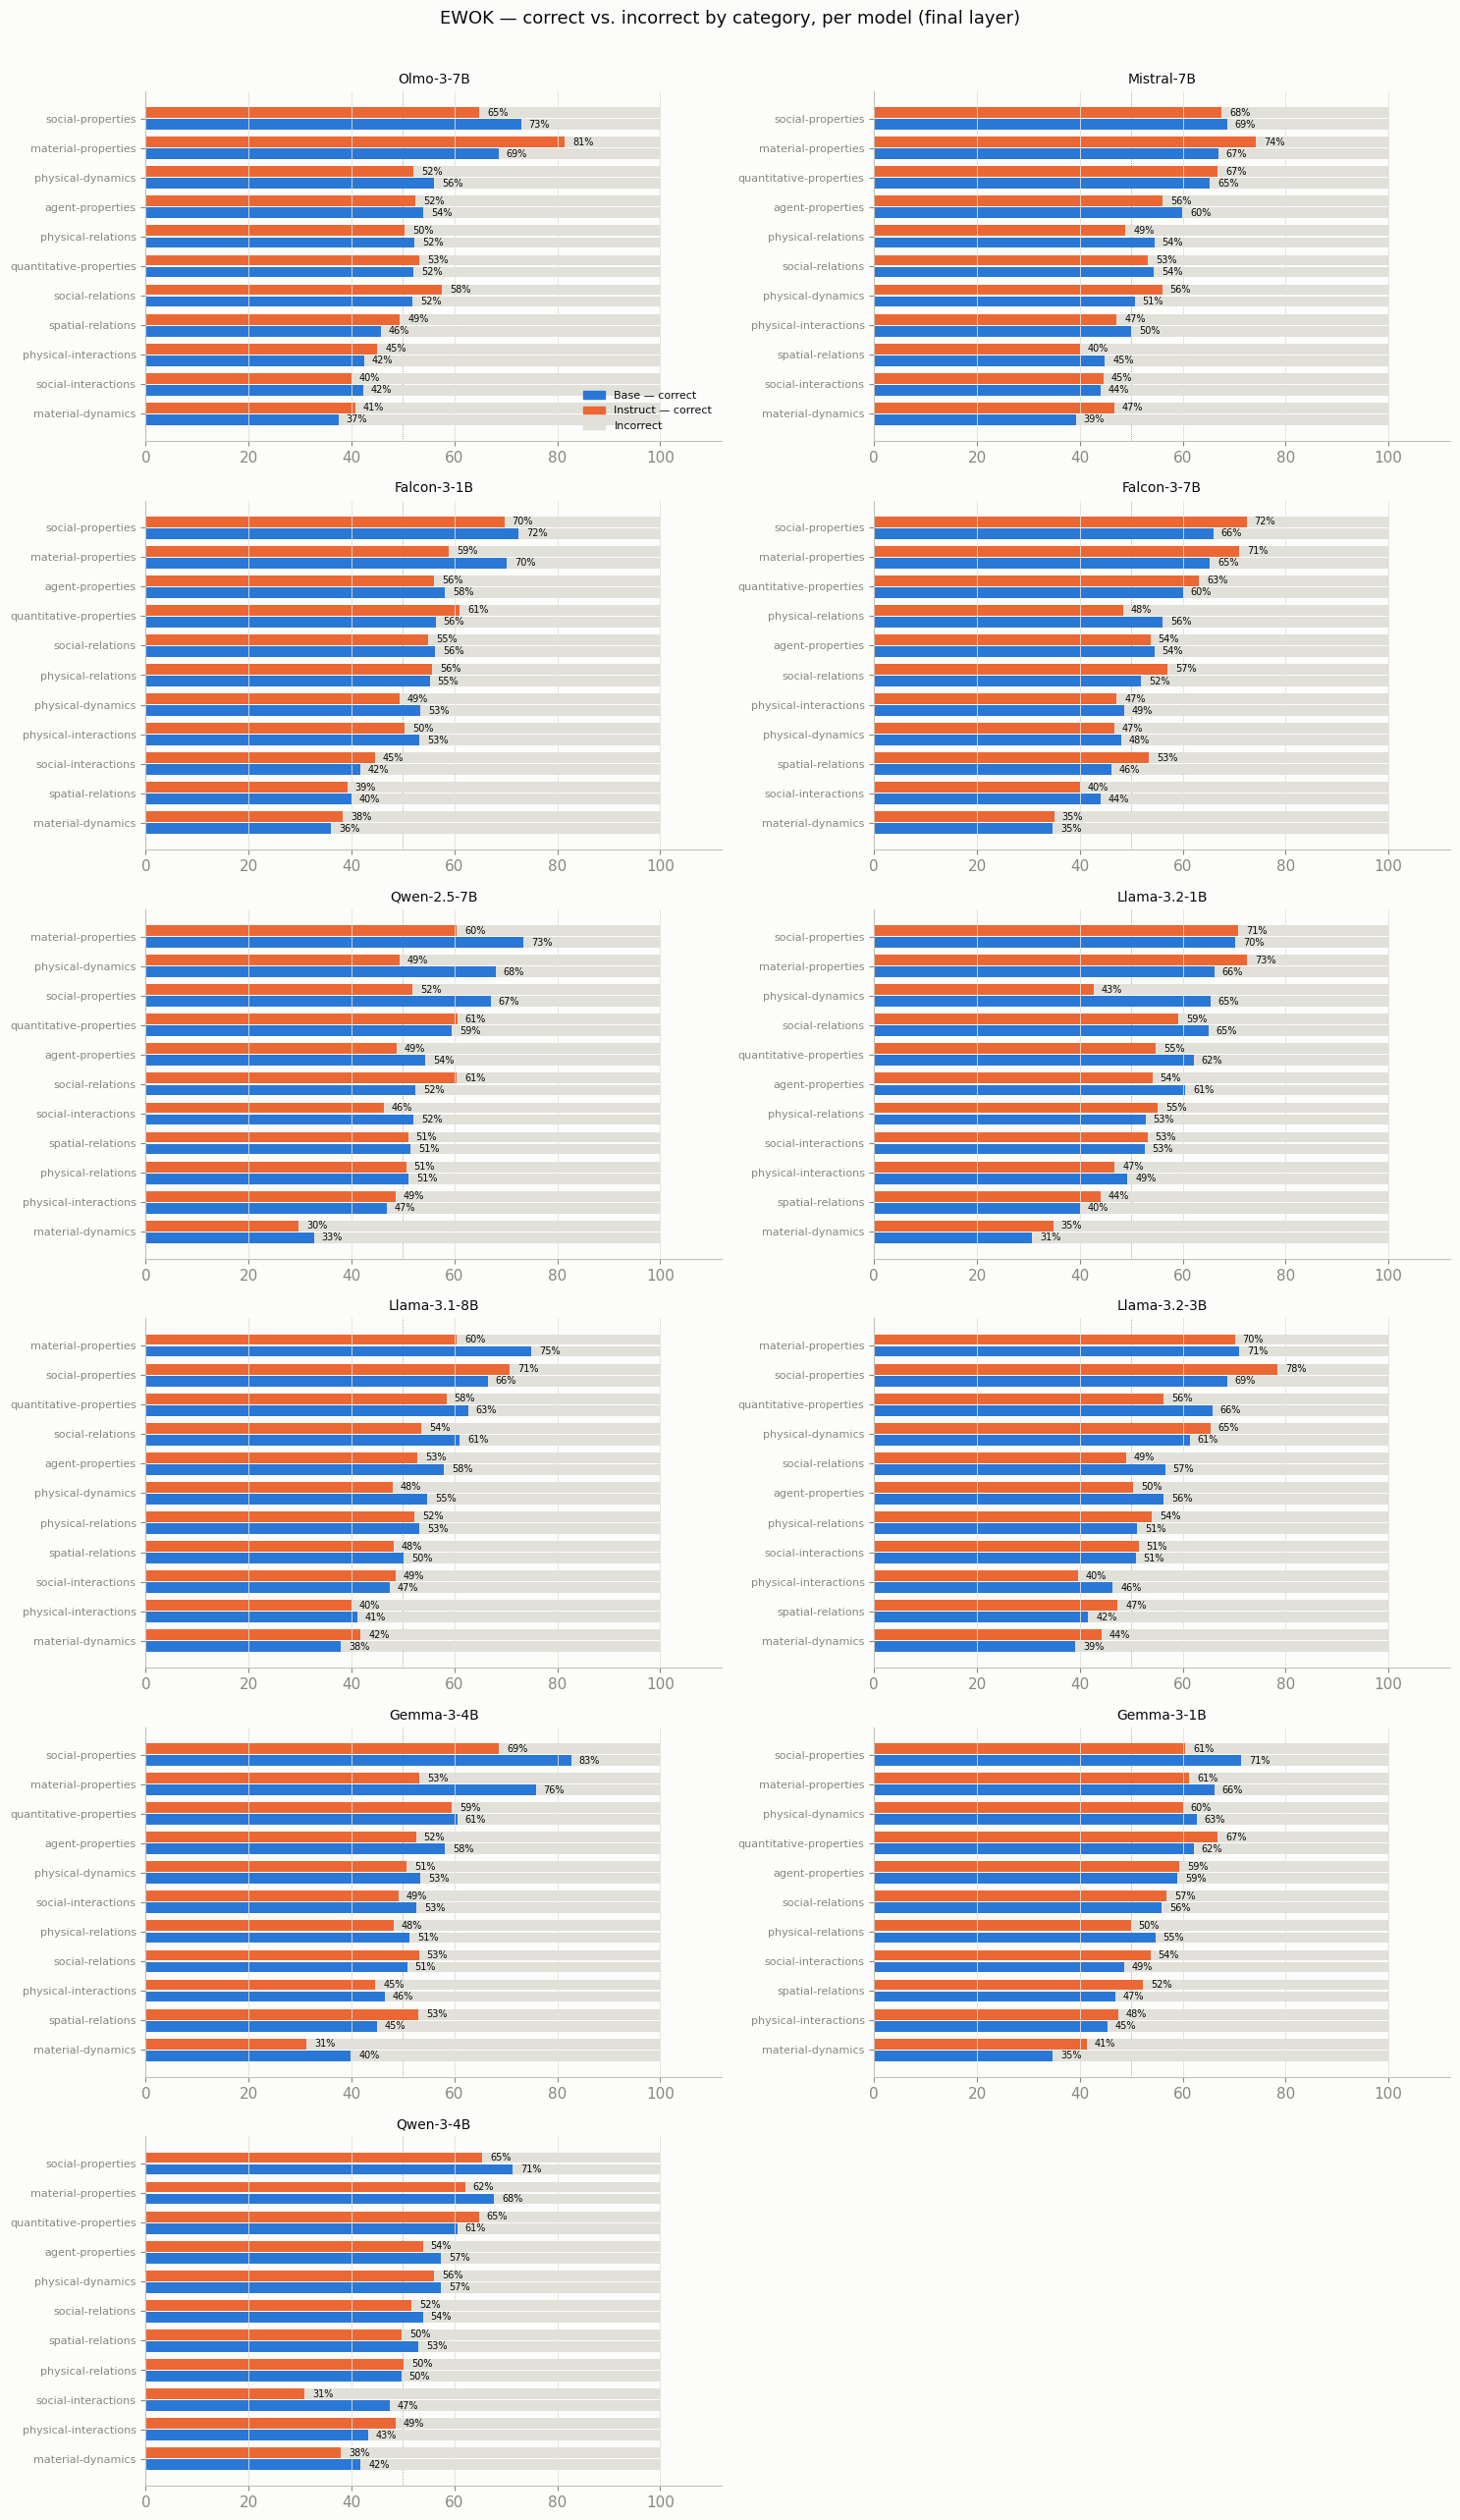

In [28]:
plot_correct_incorrect_grid("ewok")

## Notes / extensions

- **Metric.** `ACC_COL` controls which accuracy is plotted everywhere above (`acc_sum` = full-sequence logprob comparison, the standard BLiMP/EWoK metric; `acc_avg` = length-normalized per-token comparison). Re-run from the config cell after changing it.
- **Macro vs. micro averaging.** BLiMP accuracy here is macro-averaged across the 67 paradigms (each paradigm counts equally regardless of how many pairs it has); EWoK has a single pooled testsuite.
- **What 'match' means.** The matched layer is the instruction-tuned layer whose *aggregate* accuracy is numerically closest to the base model's final accuracy — it does not verify item-level agreement. A natural follow-up: correlate each sentence pair's base-model logprob with the instruction-tuned model's per-layer logprob directly (Pearson/Spearman), rather than only matching aggregate accuracy curves. That requires keeping per-item (not just per-layer-aggregated) data and is heavier to compute, so it isn't included here.
- Delete `layer_acc_cache.csv` and re-run to pick up new results.